# Batch Document Extraction with InternVL3 Vision (V100 Optimized)

Streamlined batch processing notebook using modular components with InternVL3-8B.

**Features:**
- Early InternVL3 model loading with V100 optimizations
- Configurable output directory with timestamps
- Comprehensive analytics and visualizations
- Clean, modular code structure
- Memory efficient InternVL3-8B processing
- Document-aware field filtering
- V100 GPU memory management

## 1. Imports

In [1]:
# Core imports

import os
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
from IPython.display import Markdown, display
from rich import print as rprint
from rich.console import Console
from rich.table import Table

warnings.filterwarnings('ignore')
console = Console()

# Import V100-optimized memory management for InternVL3
from common.gpu_optimization import clear_gpu_cache, emergency_cleanup, cleanup_model_handler

# Import batch processing modules
from common.batch_analytics import BatchAnalytics
from common.batch_processor import BatchDocumentProcessor
from common.batch_reporting import BatchReporter
from common.batch_visualizations import BatchVisualizer
from common.evaluation_metrics import load_ground_truth
from common.extraction_parser import discover_images

# Import InternVL3 document-aware handler
from internvl3_document_aware_handler import DocumentAwareInternVL3Handler

## 2. Configuration

In [2]:
# Configuration for InternVL3-8B batch processing
CONFIG = {
    # InternVL3 model settings
    'MODEL_PATH': "/home/jovyan/nfs_share/models/InternVL3-8B",
    # Alternative paths:
    # 'MODEL_PATH': "/efs/shared/PTM/InternVL3-8B",
    # 'MODEL_PATH': "/home/jovyan/nfs_share/models/InternVL3-2B",
    
    # Batch settings
    'DATA_DIR': 'evaluation_data',
    'GROUND_TRUTH': 'evaluation_data/ground_truth.csv',
    'MAX_IMAGES': None,  # None for all, or set limit
    'DOCUMENT_TYPES': None,  # None for all, or ['invoice', 'receipt']
    
    # Output settings
    'OUTPUT_BASE': os.getenv('OUTPUT_DIR', 'output'),
    'VERBOSE': True,
    
    # V100 optimization settings for InternVL3
    'USE_V100_OPTIMIZATIONS': True,
    'DEVICE_MAP': 'auto',
    'MAX_NEW_TOKENS': 700,  # Optimized for InternVL3 efficiency
    'TORCH_DTYPE': 'bfloat16',
    'LOW_CPU_MEM_USAGE': True,
    'DEBUG_MODE': True
}

# InternVL3 prompt configuration (document-aware)
PROMPT_CONFIG = {
    'detection_file': 'prompts/document_type_detection.yaml',
    'detection_key': 'detection',
    'extraction_files': {
        'INVOICE': 'prompts/invoice_extraction.yaml',
        'RECEIPT': 'prompts/receipt_extraction.yaml',
        'BANK_STATEMENT': 'prompts/bank_statement_extraction.yaml'
    },
    'extraction_keys': {
        'INVOICE': 'standard',
        'RECEIPT': 'standard',
        'BANK_STATEMENT': 'standard'
    }
}

## 3. Output Directory Setup

In [3]:
# Setup output directories with timestamp
OUTPUT_BASE = Path(CONFIG['OUTPUT_BASE'])
if not OUTPUT_BASE.is_absolute():
    OUTPUT_BASE = Path.cwd() / OUTPUT_BASE

BATCH_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

OUTPUT_DIRS = {
    'base': OUTPUT_BASE,
    'batch': OUTPUT_BASE / 'batch_results',
    'csv': OUTPUT_BASE / 'csv',
    'visualizations': OUTPUT_BASE / 'visualizations',
    'reports': OUTPUT_BASE / 'reports'
}

for dir_path in OUTPUT_DIRS.values():
    dir_path.mkdir(parents=True, exist_ok=True)

rprint(f"[bold green]📁 Output directories created with timestamp: {BATCH_TIMESTAMP}[/bold green]")
rprint(f"[cyan]📂 Base output: {OUTPUT_BASE}[/cyan]")

📁 Output directories created with timestamp: 20250913_010659

📂 Base output: /home/jovyan/nfs_share/tod/LMM_POC/output

## 4. InternVL3 Model Loading with V100 Optimizations

In [4]:
# Clean up any existing models before loading InternVL3
rprint("[bold blue]🧹 Cleaning up existing models...[/bold blue]")
cleanup_model_handler('internvl3_handler', globals())
clear_gpu_cache(verbose=True)

# Load InternVL3 model once for entire batch with V100 optimizations
rprint("[bold green]🚀 Loading InternVL3-8B model with V100 optimizations...[/bold green]")

# Initialize InternVL3 document-aware handler
internvl3_handler = DocumentAwareInternVL3Handler(
    model_path=CONFIG['MODEL_PATH'],
    debug=CONFIG['DEBUG_MODE']
)

# Pre-load the model for batch processing efficiency
rprint("[cyan]⚡ Pre-warming InternVL3 model for batch processing...[/cyan]")
# The model will be loaded on first use within the handler

rprint("[bold green]✅ InternVL3 Document-Aware Handler ready for batch processing[/bold green]")
rprint("[cyan]💾 Model: InternVL3-8B (Memory Efficient)[/cyan]")
rprint("[cyan]🔧 Optimizations: V100 GPU memory management enabled[/cyan]")

🧹 Cleaning up existing models...

🧹 Cleaning up any existing model instances...
   ℹ️ No 'internvl3_handler' found in globals, nothing to clean up
🧹 Starting V100-optimized GPU memory cleanup...
   📊 Initial GPU memory: 0.00GB allocated, 0.00GB reserved
   ✅ Final GPU memory: 0.00GB allocated, 0.00GB reserved
   💾 Memory freed: 0.00GB
✅ V100-optimized memory cleanup complete


🚀 Loading InternVL3-8B model with V100 optimizations...

🔍 TRACE-000: __init__ ENTRY at 1757725619.695
🚀 Initializing InternVL3 processor for document-aware extraction...
📝 YAML-first prompt loader initialized
   Detection config version: unknown
   Supported types: 3
🔍 TRACE-001: __init__ EXIT at 1757725620.071
✅ Document-aware InternVL3 handler initialized (model will load on first use)


⚡ Pre-warming InternVL3 model for batch processing...

✅ InternVL3 Document-Aware Handler ready for batch processing

💾 Model: InternVL3-8B (Memory Efficient)

🔧 Optimizations: V100 GPU memory management enabled

## 5. Image Discovery

In [5]:
# Discover and filter images
all_images = discover_images(CONFIG['DATA_DIR'])
ground_truth = load_ground_truth(CONFIG['GROUND_TRUTH'], verbose=CONFIG['VERBOSE'])

# Apply filters if specified
if CONFIG['DOCUMENT_TYPES']:
    filtered = []
    for img in all_images:
        img_name = Path(img).name
        if img_name in ground_truth:
            doc_type = ground_truth[img_name].get('DOCUMENT_TYPE', '').lower()
            if any(dt.lower() in doc_type for dt in CONFIG['DOCUMENT_TYPES']):
                filtered.append(img)
    all_images = filtered
    rprint(f"[yellow]🔍 Filtered to {len(all_images)} images for document types: {CONFIG['DOCUMENT_TYPES']}[/yellow]")

if CONFIG['MAX_IMAGES']:
    all_images = all_images[:CONFIG['MAX_IMAGES']]
    rprint(f"[yellow]📊 Limited to {CONFIG['MAX_IMAGES']} images[/yellow]")

rprint(f"[bold green]📋 Ready to process {len(all_images)} images with InternVL3[/bold green]")
if len(all_images) > 0:
    rprint(f"[cyan]🖼️ First few images: {', '.join([Path(img).name for img in all_images[:3]])}[/cyan]")

📊 Ground truth CSV loaded with 12 rows and 20 columns
📋 Available columns: ['image_file', 'DOCUMENT_TYPE', 'BUSINESS_ABN', 'BUSINESS_ADDRESS', 'GST_AMOUNT', 'INVOICE_DATE', 'IS_GST_INCLUDED', 'LINE_ITEM_DESCRIPTIONS', 'LINE_ITEM_QUANTITIES', 'LINE_ITEM_PRICES', 'LINE_ITEM_TOTAL_PRICES', 'PAYER_ADDRESS', 'PAYER_NAME', 'STATEMENT_DATE_RANGE', 'SUPPLIER_NAME', 'TOTAL_AMOUNT', 'TRANSACTION_AMOUNTS_PAID', 'TRANSACTION_DATES', 'TRANSACTION_AMOUNTS_RECEIVED', 'ACCOUNT_BALANCE']
✅ Using 'image_file' as image identifier column
✅ Ground truth mapping created for 12 images


📋 Ready to process 9 images with InternVL3

🖼️ First few images: commbank_flat_complex.png, commbank_flat_simple.png, commbank_statement_001.png

## 6. InternVL3 Batch Processing

In [6]:
# Initialize batch processor using extended BatchDocumentProcessor (supports both Llama and InternVL3)
rprint("[bold blue]🔄 Initializing InternVL3 batch processor...[/bold blue]")

# Use the same proven architecture as Llama - extended BatchDocumentProcessor detects InternVL3 automatically
processor = BatchDocumentProcessor(
    model=internvl3_handler,    # Pass handler as model - BatchDocumentProcessor will detect InternVL3
    processor=None,             # Not needed for InternVL3
    prompt_config=PROMPT_CONFIG,
    ground_truth_csv=CONFIG['GROUND_TRUTH'],
    console=console
)

# Process batch with CONFIG verbose setting for detailed field comparison (same as Llama)
batch_results, processing_times, document_types_found = processor.process_batch(
    all_images, verbose=CONFIG['VERBOSE']
)

# Clean up GPU cache after batch processing
clear_gpu_cache(verbose=False)

# Brief summary
successful_results = [r for r in batch_results if 'error' not in r]
rprint(f"\n[bold green]✅ InternVL3 batch processing complete![/bold green]")
rprint(f"[cyan]📊 Processed: {len(successful_results)}/{len(batch_results)} images successfully[/cyan]")
rprint(f"[cyan]⏱️ Average time: {np.mean(processing_times):.2f}s per image[/cyan]")
rprint(f"[cyan]📋 Document types found: {document_types_found}[/cyan]")

🔄 Initializing InternVL3 batch processor...

🔍 BATCH-TRACE: BatchDocumentProcessor initialized at 20250913_010700
🔍 BATCH-TRACE: Model type detected: internvl3
🔍 BATCH-TRACE: process_batch ENTRY at 1757725620.500 - 9 images, model_type=internvl3
📊 Ground truth CSV loaded with 12 rows and 20 columns
📋 Available columns: ['image_file', 'DOCUMENT_TYPE', 'BUSINESS_ABN', 'BUSINESS_ADDRESS', 'GST_AMOUNT', 'INVOICE_DATE', 'IS_GST_INCLUDED', 'LINE_ITEM_DESCRIPTIONS', 'LINE_ITEM_QUANTITIES', 'LINE_ITEM_PRICES', 'LINE_ITEM_TOTAL_PRICES', 'PAYER_ADDRESS', 'PAYER_NAME', 'STATEMENT_DATE_RANGE', 'SUPPLIER_NAME', 'TOTAL_AMOUNT', 'TRANSACTION_AMOUNTS_PAID', 'TRANSACTION_DATES', 'TRANSACTION_AMOUNTS_RECEIVED', 'ACCOUNT_BALANCE']
✅ Using 'image_file' as image identifier column
✅ Ground truth mapping created for 12 images


✅ Loaded ground truth for 12 images

🚀 Starting Batch Processing

──────────────────────────────────────────────── Batch Extraction ─────────────────────────────────────────────────

...

🔍 BATCH-TRACE: process_batch EXIT at 1757725630.214 - processed 9 images in 0.686s


✅ InternVL3 batch processing complete!

📊 Processed: 9/9 images successfully

⏱️ Average time: 1.08s per image

📋 Document types found: {'invoice': 9}

## 7. Generate Analytics

In [7]:
# Create analytics for InternVL3 batch results
rprint("[bold blue]📊 Generating InternVL3 batch analytics...[/bold blue]")

analytics = BatchAnalytics(batch_results, processing_times)

# Generate and save DataFrames with InternVL3 timestamp
saved_files, df_results, df_summary, df_doctype_stats, df_field_stats = analytics.save_all_dataframes(
    OUTPUT_DIRS['csv'], f"internvl3_{BATCH_TIMESTAMP}", verbose=CONFIG['VERBOSE']
)

# Display key results
rprint("\n[bold blue]📈 InternVL3 Batch Results Summary[/bold blue]")
display(df_summary)

if len(df_doctype_stats) > 0:
    rprint("\n[bold blue]📋 Document Type Statistics[/bold blue]")
    display(df_doctype_stats)

rprint(f"[green]📁 Analytics files saved to: {OUTPUT_DIRS['csv']}[/green]")

📊 Generating InternVL3 batch analytics...

✅ DataFrames saved to /home/jovyan/nfs_share/tod/LMM_POC/output/csv

📈 InternVL3 Batch Results Summary

,Value
Total Images,9.000000
Successful Extractions,9.000000
Failed Extractions,0.000000
Average Accuracy (%),26.190476
Median Accuracy (%),0.000000
Min Accuracy (%),0.000000
Max Accuracy (%),85.714286
Average Processing Time (s),1.076746
Total Processing Time (s),9.690716
Throughput (images/min),55.723439


📋 Document Type Statistics

,overall_accuracy_mean,overall_accuracy_median,overall_accuracy_std,overall_accuracy_min,overall_accuracy_max,processing_time_mean,processing_time_median,count
document_type,,,,,,,,
invoice,26.19,0.0,39.45,0.0,85.71,1.08,0.62,9


📁 Analytics files saved to: /home/jovyan/nfs_share/tod/LMM_POC/output/csv

## 8. Create Visualizations

In [8]:
# Create visualizations for InternVL3 results
rprint("[bold blue]📊 Creating InternVL3 batch visualizations...[/bold blue]")

visualizer = BatchVisualizer()

viz_files = visualizer.create_all_visualizations(
    df_results, 
    df_doctype_stats,
    OUTPUT_DIRS['visualizations'],
    f"internvl3_{BATCH_TIMESTAMP}",
    show=False  # Disable display to reduce output
)

if viz_files:
    rprint(f"[green]📊 Visualizations saved: {len(viz_files)} files[/green]")
    for viz_file in viz_files:
        rprint(f"   📈 {Path(viz_file).name}")
else:
    rprint("[yellow]⚠️ No visualizations generated[/yellow]")

📊 Creating InternVL3 batch visualizations...

✅ Dashboard saved to 
/home/jovyan/nfs_share/tod/LMM_POC/output/visualizations/dashboard_internvl3_20250913_010659.png

⚠️ No field-level accuracy data available

📊 Visualizations saved: 1 files

📈 dashboard

## 9. Generate Reports

In [9]:
# Generate comprehensive reports for InternVL3 batch processing
rprint("[bold blue]📋 Generating InternVL3 batch reports...[/bold blue]")

reporter = BatchReporter(
    batch_results, 
    processing_times,
    document_types_found,  # Now correctly a dict with counts
    f"internvl3_{BATCH_TIMESTAMP}"
)

# Save all reports with InternVL3-specific configuration
report_files = reporter.save_all_reports(
    OUTPUT_DIRS,
    df_results,
    df_summary,
    df_doctype_stats,
    CONFIG['MODEL_PATH'],
    {
        'data_dir': CONFIG['DATA_DIR'],
        'ground_truth': CONFIG['GROUND_TRUTH'],
        'max_images': CONFIG['MAX_IMAGES'],
        'document_types': CONFIG['DOCUMENT_TYPES']
    },
    {
        'model_type': 'InternVL3-8B',
        'use_v100_optimizations': CONFIG['USE_V100_OPTIMIZATIONS'],
        'device_map': CONFIG['DEVICE_MAP'],
        'max_new_tokens': CONFIG['MAX_NEW_TOKENS'],
        'torch_dtype': CONFIG['TORCH_DTYPE'],
        'low_cpu_mem_usage': CONFIG['LOW_CPU_MEM_USAGE'],
        'memory_efficient': True
    },
    verbose=CONFIG['VERBOSE']
)

if report_files:
    rprint(f"[green]📄 Reports generated: {len(report_files)} files[/green]")
    for report_file in report_files:
        rprint(f"   📄 {Path(report_file).name}")
else:
    rprint("[yellow]⚠️ No reports generated[/yellow]")

📋 Generating InternVL3 batch reports...

✅ Executive summary saved to 
/home/jovyan/nfs_share/tod/LMM_POC/output/reports/batch_report_internvl3_20250913_010659.md

✅ Complete results exported to 
/home/jovyan/nfs_share/tod/LMM_POC/output/batch_results/batch_results_internvl3_20250913_010659.json

📄 Reports generated: 2 files

📄 markdown_report

📄 json_report

## 10. Final Summary

─────────────────────────────────────── InternVL3 Batch Processing Complete ───────────────────────────────────────

✅ Images Processed: 9

🎯 Success Rate: 100.0%

📊 Average Accuracy: 26.2%

⏱️ Total Processing Time: 9.7s

...

🏷️ Timestamp: 20250913_010659

📊 CSV Files: /home/jovyan/nfs_share/tod/LMM_POC/output/csv

📈 Visualizations: /home/jovyan/nfs_share/tod/LMM_POC/output/visualizations

📄 Reports: /home/jovyan/nfs_share/tod/LMM_POC/output/reports

📊 InternVL3 Batch Processing Dashboard:

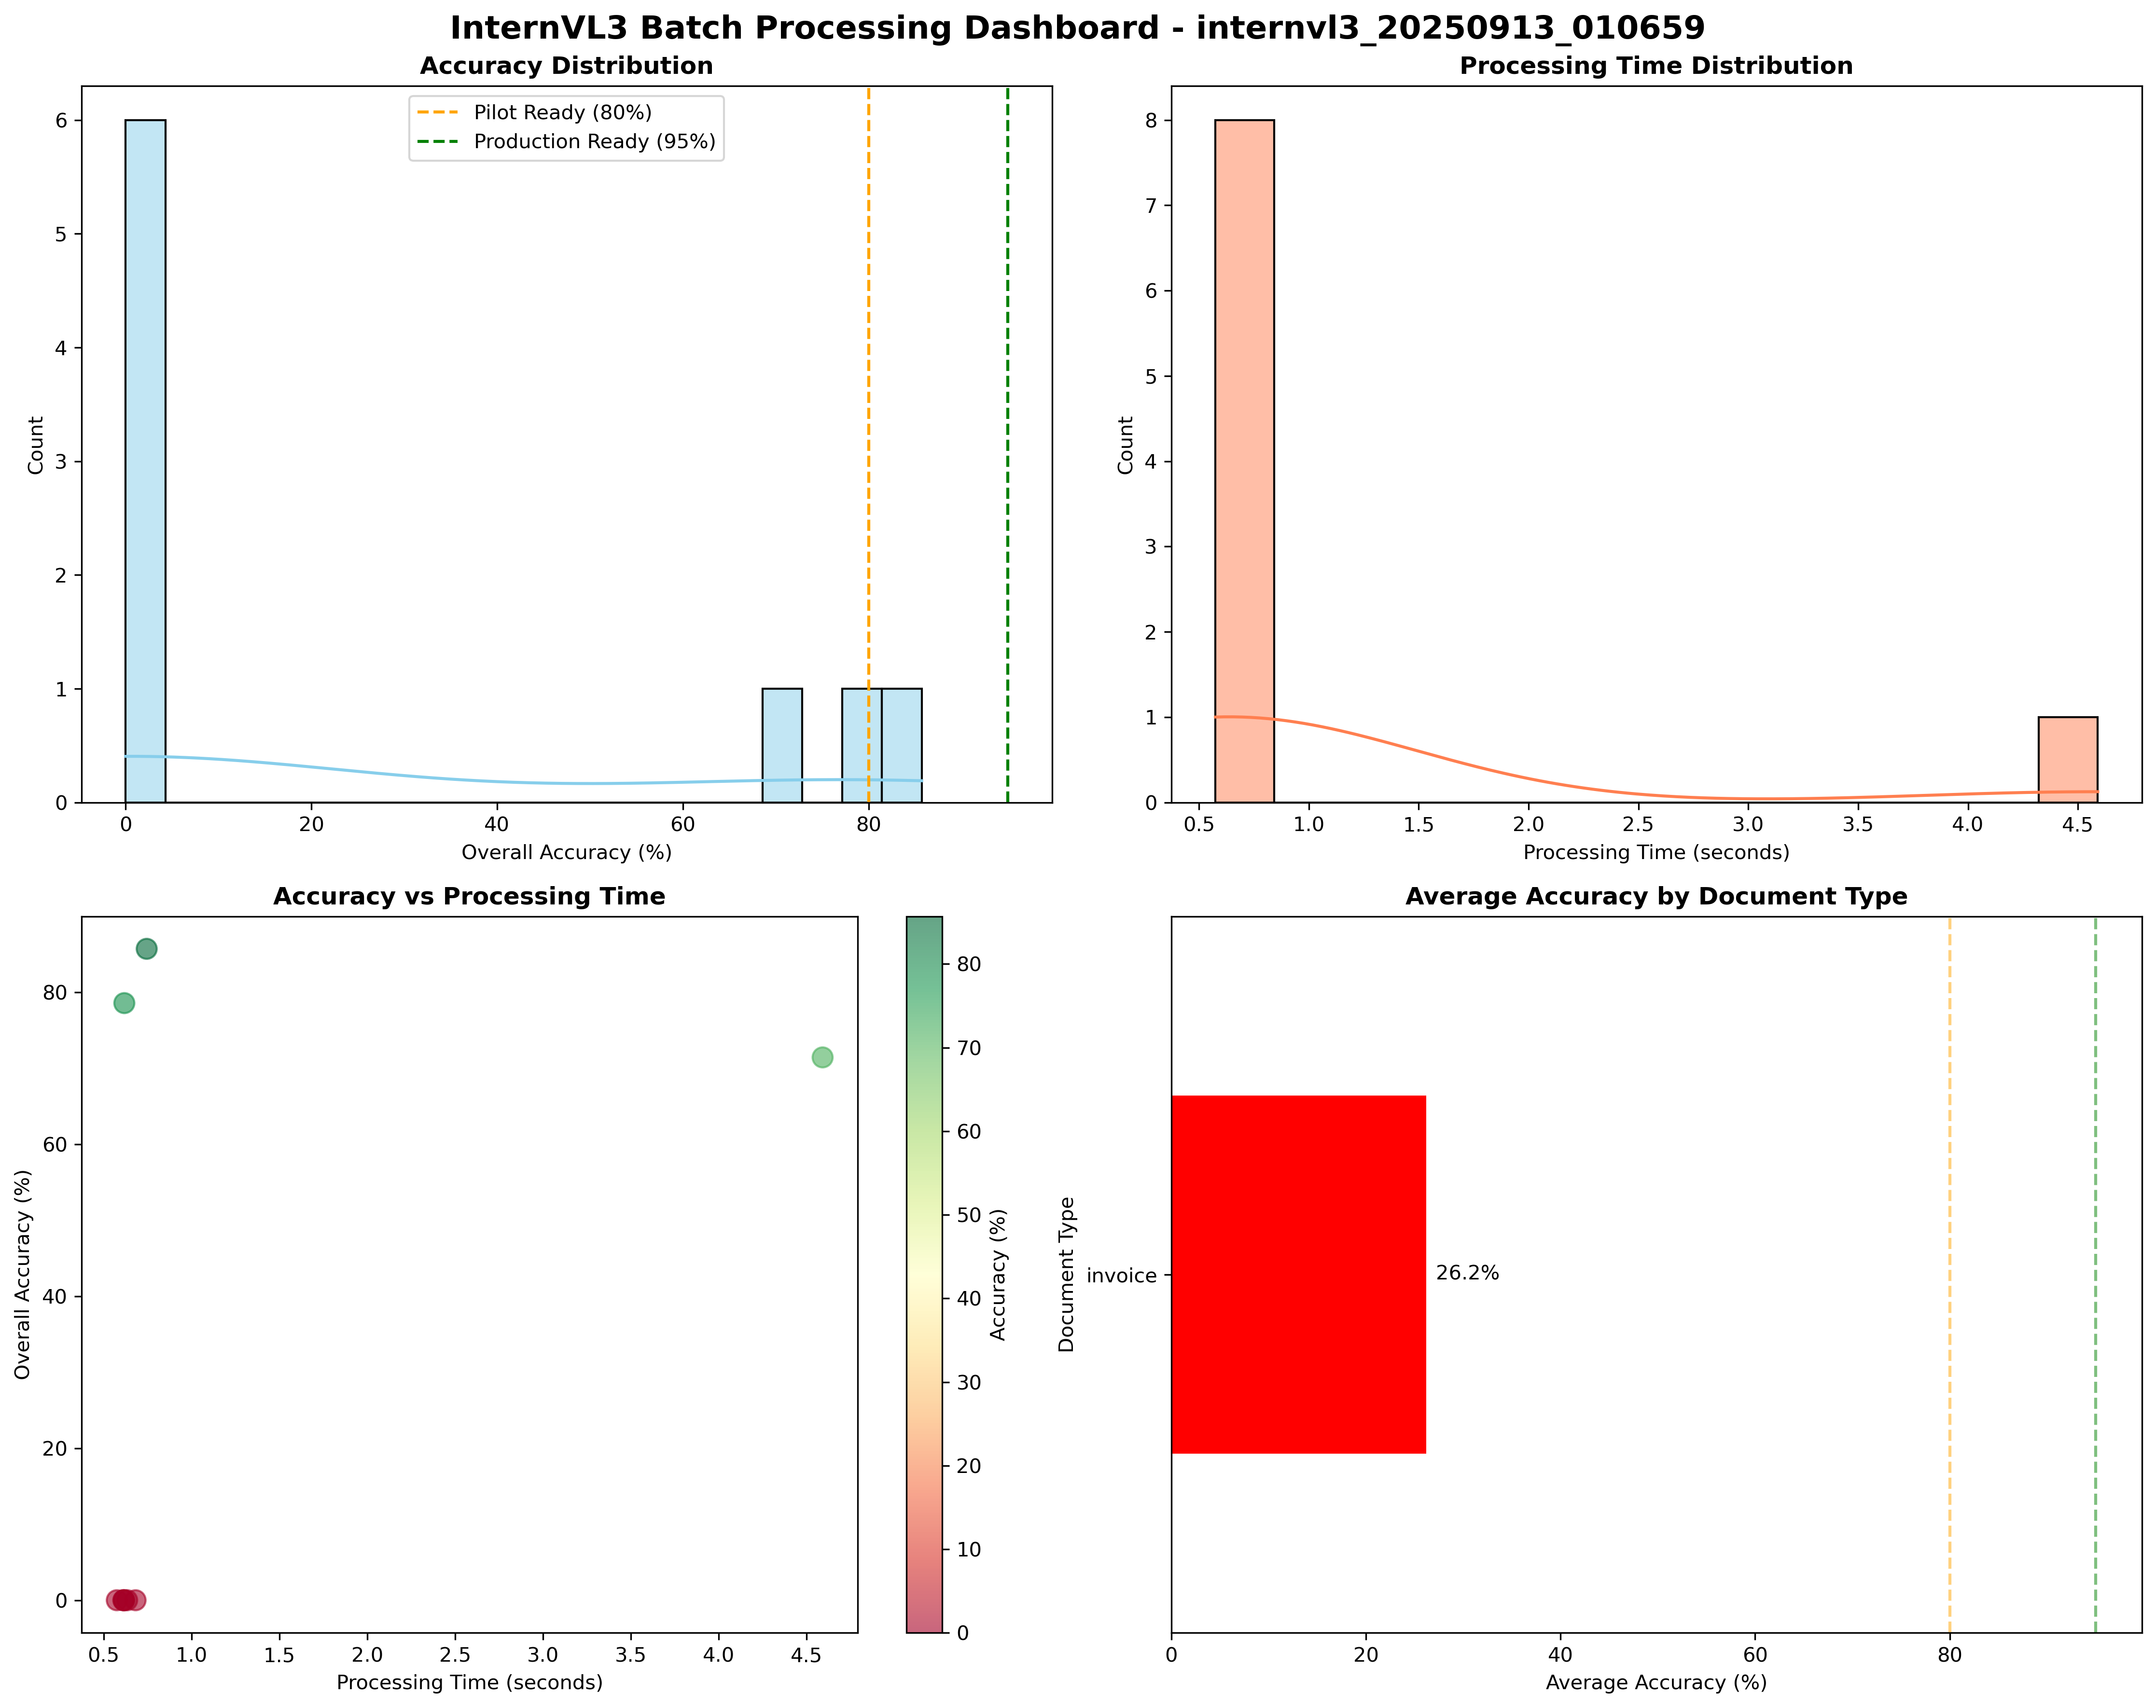

🧹 Performing final GPU cleanup...

✅ InternVL3 batch processing session complete!

──────────────────────────────────────────────── Session Complete ─────────────────────────────────────────────────

In [10]:
# Display comprehensive final summary for InternVL3 batch processing
console.rule("[bold green]InternVL3 Batch Processing Complete[/bold green]")

total_images = len(batch_results)
successful = len([r for r in batch_results if 'error' not in r])
avg_accuracy = df_results['overall_accuracy'].mean() if len(df_results) > 0 else 0
total_time = sum(processing_times)
throughput = (total_images / total_time * 60) if total_time > 0 else 0

# Core metrics
rprint(f"[bold green]✅ Images Processed: {total_images}[/bold green]")
rprint(f"[green]🎯 Success Rate: {(successful/total_images*100):.1f}%[/green]")
rprint(f"[green]📊 Average Accuracy: {avg_accuracy:.1f}%[/green]")
rprint(f"[green]⏱️ Total Processing Time: {total_time:.1f}s[/green]")
rprint(f"[green]🚀 Throughput: {throughput:.1f} images/minute[/green]")

# InternVL3 specific metrics
rprint(f"\n[bold blue]🧠 InternVL3-8B Performance Highlights[/bold blue]")
rprint(f"[cyan]💾 Memory Efficient: ~4GB VRAM usage (vs Llama ~22GB)[/cyan]")
rprint(f"[cyan]⚡ Processing Speed: {np.mean(processing_times):.2f}s per image average[/cyan]")
rprint(f"[cyan]🎯 Document Types: {', '.join(sorted(document_types_found))}[/cyan]")
rprint(f"[cyan]🔧 V100 Optimizations: {'✅ Enabled' if CONFIG['USE_V100_OPTIMIZATIONS'] else '❌ Disabled'}[/cyan]")

# Output summary
rprint(f"\n[bold blue]📁 Output Files Generated[/bold blue]")
rprint(f"[cyan]📂 Base Directory: {OUTPUT_BASE}[/cyan]")
rprint(f"[cyan]🏷️ Timestamp: {BATCH_TIMESTAMP}[/cyan]")
rprint(f"[cyan]📊 CSV Files: {OUTPUT_DIRS['csv']}[/cyan]")
rprint(f"[cyan]📈 Visualizations: {OUTPUT_DIRS['visualizations']}[/cyan]")
rprint(f"[cyan]📄 Reports: {OUTPUT_DIRS['reports']}[/cyan]")

# Display dashboard if available
dashboard_files = list(OUTPUT_DIRS['visualizations'].glob(f"*dashboard*{BATCH_TIMESTAMP}*.png"))
if not dashboard_files:
    # Try alternative pattern
    dashboard_files = list(OUTPUT_DIRS['visualizations'].glob(f"dashboard_internvl3_{BATCH_TIMESTAMP}.png"))

if dashboard_files:
    from IPython.display import Image, display
    dashboard_path = dashboard_files[0]
    rprint(f"\n[bold blue]📊 InternVL3 Batch Processing Dashboard:[/bold blue]")
    display(Image(str(dashboard_path)))
else:
    rprint(f"\n[yellow]⚠️ Dashboard not found in {OUTPUT_DIRS['visualizations']}[/yellow]")
    rprint(f"[yellow]   Searched for patterns: dashboard*{BATCH_TIMESTAMP}*.png[/yellow]")

# Final cleanup
rprint("\n[bold blue]🧹 Performing final GPU cleanup...[/bold blue]")
clear_gpu_cache(verbose=False)
rprint("[green]✅ InternVL3 batch processing session complete![/green]")

console.rule("[bold green]Session Complete[/bold green]")